In [1]:
%matplotlib widget
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double
# dim: int or "Any"

import sphWarpCore as sph
from sphWarpCore.type_config import *

print(get_type_config()) # confirms active settings

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
from compressibleSPH.enumTypes import *

nx = 64
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
from compressibleSPH.schemeBuilder import buildScheme


L = 2
dim = 2
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()


domain = buildDomainDescription(l = L, dim = dim, periodic = True, device = device, dtype = dtype)
# domain.min = torch.tensor([0, 0], device = device, dtype = dtype)
# domain.max = torch.tensor([1, 1], device = device, dtype = dtype)

config = SimulationConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = True,
    cflFactor=0.3,
    verletScale=1.0
)
config.nx = nx
config.dx = 1 / config.nx

# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('MonaghanCompressibleSPH')
# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('compSPH')
SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('crkSPH')

schemeConfig = SimulationConfig()
schemeConfig.gamma = gamma
schemeConfig.rho0 = leftState.rho
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins
schemeConfig.viscositySwitchParams.correctVelocityGradient = True
schemeConfig.adaptiveSupportCorrections = False

display(schemeConfig)

# diffusionParams = DiffusionParameters()
# diffusionParams.c_s = 1
# diffusionParams.C_l = 1
# diffusionParams.C_q = 2
# diffusionParams.Cu_l = 1
# diffusionParams.Cu_q = 2
# diffusionParams.K = 1.0
# diffusionParams.thermalConductivity = 0.5
# diffusionParams.viscosityTerm = ViscosityTerms.Monaghan1992.value
# diffusionParams.thermalConducitiyTerm = ViscosityTerms.Price2012_98.value
# diffusionParams.scaleBeta = False
# diffusionParams.monaghanSwitch = True
# diffusionParams.correctXi = True

# compressibleSPHConfig = CompressibleSPHConfig(
#     gamma = gamma,
#     rho0 = leftState.rho,
#     diffusionParams = diffusionParams,
# )
# integrator = getIntegrator(config.integrationScheme)

schemeConfig.crkViscosityParams.enableCRKLimiter = False


CRKSPHConfig(gamma=1.6666666666666667, backgroundPressure=0.0, rho0=1, adaptiveSupportScheme=<AdaptiveSupportScheme.Owen: 2>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=False, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=2,
	Cu_l=1,
	Cu_q=2,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.CullenHopkins: 3>, limitXi=True, correctVelocityGradient=True, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CRKSPH', energyScheme=<EnergyScheme.CRK: 5>, crkViscosityParams=CRKViscosity(
	eta_fold=float32(0),
	eta_crit=float32(0),
	enableCRKLimiter=bool(False),
	enableVanLeerLimiter=bool(False),
	forceVanLeerOff=bool(False),
	forceVanLeerOn=bool(False),
))

In [3]:


particles_ = sampleRegularParticles(nx, config.domain, config.targetNeighbors)
# domain = buildDomainDescription(domainExtent * 1.5, dim, periodic = periodicDomain, device = device, dtype = dtype)
particles_ = particles_._replace(masses = particles_.masses * schemeConfig.rho0)


print(f"Sampled {particles_.positions.shape[0]} particles.")
print(f' Support: Min: {particles_.supports.min().item()}, Max: {particles_.supports.max().item()}, Mean: {particles_.supports.mean().item()}')

particles = SimulationState(
    positions = particles_.positions,
    supports = particles_.supports,
    masses = particles_.masses,
    densities = particles_.densities,
    velocities = torch.zeros_like(particles_.positions),
    
    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles_.positions.shape[0],
    
    internalEnergies = None,
    totalEnergies = None,
    entropies = None,
    pressures = None,
    soundspeeds = None,

    divergence=torch.zeros_like(particles_.densities),
    alpha0s= torch.ones_like(particles_.densities),
    alphas= torch.ones_like(particles_.densities),
)


Sampled 4096 particles.
 Support: Min: 0.125, Max: 0.125, Mean: 0.125


In [4]:
from compressibleSPH.modules.liu.wp_mat import computeLiuMatricesWarp

q = particles.positions[:,0]

queryPositions = torch.rand((256, 2), device = device) * 1.8 - 0.9

b, A_g, neighCounts = computeLiuMatricesWarp(
    queryPositions = queryPositions,
    referenceParticles = particles,
    referenceQuantities = q,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = SupportScheme.Scatter,
    ),
    domain = config.domain,
)

Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 2.49 ms  (cached)
Module compressibleSPH.modules.liu.wp_mat e6edb79 load on device 'cuda:0' took 4709.69 ms  (compiled)


In [5]:
A_g_inv = torch.zeros_like(A_g)
A_g_inv[neighCounts > 4] = torch.linalg.pinv(A_g[neighCounts > 4])

res = torch.matmul(A_g_inv, b.unsqueeze(2))[:,:,0]

print(res)

tensor([[-7.4231e-01,  1.0000e+00, -1.0343e-04],
        [ 2.9195e-01,  1.0000e+00,  1.1248e-04],
        [-5.2201e-01,  9.9974e-01,  6.4012e-05],
        [-8.4443e-01,  9.9995e-01,  8.4898e-04],
        [ 8.5354e-01,  9.9978e-01,  1.6362e-04],
        [-2.0354e-01,  1.0000e+00, -3.2822e-06],
        [-3.5736e-01,  9.9991e-01, -2.1367e-04],
        [ 2.2713e-01,  9.9983e-01,  2.5148e-05],
        [ 1.3098e-01,  9.9995e-01, -6.3849e-05],
        [-3.8510e-01,  9.9997e-01,  1.0631e-04],
        [ 6.6188e-01,  1.0003e+00,  2.0348e-04],
        [ 3.4110e-01,  1.0001e+00,  1.4229e-04],
        [ 5.2071e-01,  1.0001e+00, -1.6712e-04],
        [-7.9052e-02,  1.0000e+00, -2.8743e-05],
        [-2.1039e-01,  1.0001e+00, -2.4296e-05],
        [ 4.9918e-01,  9.9997e-01,  4.4809e-04],
        [-1.5458e-01,  9.9998e-01, -1.2146e-04],
        [ 6.4079e-01,  1.0000e+00,  3.6763e-04],
        [ 2.0128e-01,  9.9993e-01,  8.5403e-05],
        [-4.8050e-02,  1.0000e+00, -3.5122e-05],
        [ 7.7479e-01

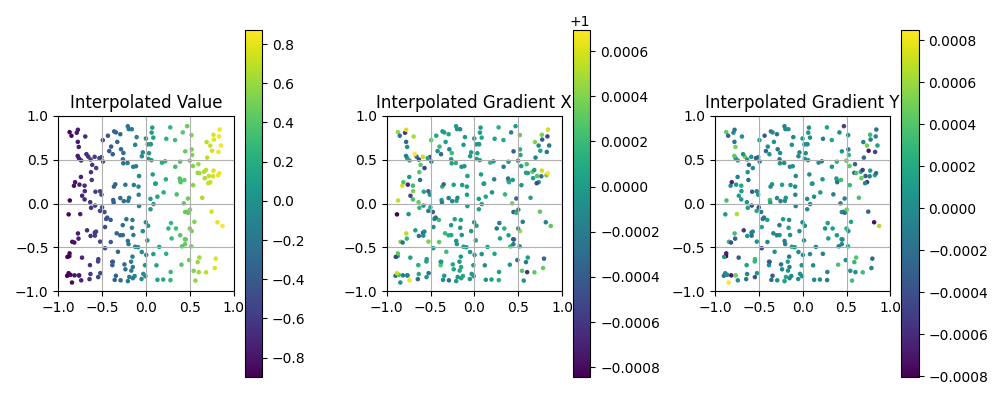

In [6]:
fig, axis = plt.subplots(1, 3, figsize=(10,4), squeeze=False)

sc = axis[0,0].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c=res[:,0].cpu(), s=5, cmap='viridis')
plt.colorbar(sc, ax=axis[0,0])

sc = axis[0,1].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c=res[:,1].cpu(), s=5, cmap='viridis')
plt.colorbar(sc, ax=axis[0,1])

sc = axis[0,2].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c=res[:,2].cpu(), s=5, cmap='viridis')
plt.colorbar(sc, ax=axis[0,2])

axis[0,0].set_title("Interpolated Value")
axis[0,1].set_title("Interpolated Gradient X")
axis[0,2].set_title("Interpolated Gradient Y")

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].cpu().item(), config.domain.max[0].cpu().item())
    ax.set_ylim(config.domain.min[1].cpu().item(), config.domain.max[1].cpu().item())
    ax.grid()

fig.tight_layout()

In [7]:
res

tensor([[-7.4231e-01,  1.0000e+00, -1.0343e-04],
        [ 2.9195e-01,  1.0000e+00,  1.1248e-04],
        [-5.2201e-01,  9.9974e-01,  6.4012e-05],
        [-8.4443e-01,  9.9995e-01,  8.4898e-04],
        [ 8.5354e-01,  9.9978e-01,  1.6362e-04],
        [-2.0354e-01,  1.0000e+00, -3.2822e-06],
        [-3.5736e-01,  9.9991e-01, -2.1367e-04],
        [ 2.2713e-01,  9.9983e-01,  2.5148e-05],
        [ 1.3098e-01,  9.9995e-01, -6.3849e-05],
        [-3.8510e-01,  9.9997e-01,  1.0631e-04],
        [ 6.6188e-01,  1.0003e+00,  2.0348e-04],
        [ 3.4110e-01,  1.0001e+00,  1.4229e-04],
        [ 5.2071e-01,  1.0001e+00, -1.6712e-04],
        [-7.9052e-02,  1.0000e+00, -2.8743e-05],
        [-2.1039e-01,  1.0001e+00, -2.4296e-05],
        [ 4.9918e-01,  9.9997e-01,  4.4809e-04],
        [-1.5458e-01,  9.9998e-01, -1.2146e-04],
        [ 6.4079e-01,  1.0000e+00,  3.6763e-04],
        [ 2.0128e-01,  9.9993e-01,  8.5403e-05],
        [-4.8050e-02,  1.0000e+00, -3.5122e-05],
        [ 7.7479e-01

In [5]:
liuState[0]

tensor([[-3.8877e-01,  1.0001e+00,  1.6231e-04],
        [-6.0818e-01,  9.9993e-01,  4.3249e-04],
        [-7.5403e-01,  1.0004e+00,  9.5637e-05],
        [ 1.5264e-01,  1.0000e+00, -9.3755e-05],
        [-1.5494e-01,  9.9998e-01, -1.3771e-04],
        [-3.4427e-01,  1.0000e+00, -3.5234e-04],
        [ 7.4203e-01,  9.9944e-01, -1.1921e-06],
        [-8.7253e-01,  9.9967e-01,  3.9244e-04],
        [ 8.7321e-01,  1.0001e+00, -8.4916e-04],
        [ 3.7816e-01,  1.0001e+00, -3.0473e-04],
        [ 5.1989e-01,  9.9973e-01, -5.4360e-05],
        [ 1.9234e-01,  1.0001e+00,  8.4931e-05],
        [-7.3472e-01,  1.0000e+00,  4.3559e-04],
        [-7.6740e-01,  1.0001e+00, -5.4359e-04],
        [-7.6361e-01,  1.0002e+00, -3.5137e-05],
        [ 2.6509e-01,  1.0000e+00,  1.7548e-04],
        [-2.7935e-01,  9.9988e-01, -4.6551e-05],
        [-8.8569e-01,  9.9939e-01,  2.3079e-04],
        [ 6.5054e-01,  1.0004e+00, -2.2487e-04],
        [-5.1129e-01, -2.4893e+01,  2.8881e-04],
        [ 8.9205e-02

In [6]:
queryState = particles.initializeNewState()
queryState.positions = queryPositions

In [7]:
    # b_scalar = SPHOperationCompiled(
    #     particles,
    #     quantity = quantities,
    #     neighborhood= neighborhood[0],
    #     kernelValues= neighborhood[1],
    #     operation = Operation.Interpolate,
    #     supportScheme= supportScheme,        
    # )
    # b_grad = SPHOperationCompiled(
    #     particles,
    #     quantity = quantities,
    #     neighborhood= neighborhood[0],
    #     kernelValues= neighborhood[1],
    #     operation = Operation.Gradient,
    #     gradientMode = GradientMode.Naive,
    #     supportScheme= supportScheme,        
    # )

b_scalar = warpOperation(
        queryParticles = queryState,
        referenceParticles = particles,
        queryValues = torch.ones_like(queryState.positions[:,0]),
        referenceValues = q,
        operationProperties = OperationProperties(
            kernel = config.kernel,
            supportMode = SupportScheme.Scatter,
            operation = WarpOperation.Interpolate,
        ),
        adjacency = None,
        domain = config.domain,
    )
b_grad = warpOperation(
        queryParticles = queryState,
        referenceParticles = particles,
        queryValues = torch.ones_like(queryState.positions[:,0]),
        referenceValues = q,
        operationProperties = OperationProperties(
            kernel = config.kernel,
            supportMode = SupportScheme.Scatter,
            operation = WarpOperation.Gradient,
            gradientMode = GradientScheme.Naive
        ),
        adjacency = None,
        domain = config.domain,
    )

Module sphWarpCore.operations_grid.wp_interpolate_grid d6f89dc load on device 'cuda:0' took 7.12 ms  (cached)
Module sphWarpCore.operations_grid.wp_gradient_grid 004f1d8 load on device 'cuda:0' took 8.89 ms  (cached)


In [8]:
b = torch.cat([b_scalar.view(-1,1), b_grad], dim = 1)
print(b.shape, liuState[0].shape)

torch.Size([32, 3]) torch.Size([32, 3])


In [9]:
print(b)

tensor([[-3.8877e-01,  1.0001e+00,  1.6231e-04],
        [-6.0818e-01,  9.9993e-01,  4.3249e-04],
        [-7.5403e-01,  1.0004e+00,  9.5637e-05],
        [ 1.5264e-01,  1.0000e+00, -9.3755e-05],
        [-1.5494e-01,  9.9998e-01, -1.3771e-04],
        [-3.4427e-01,  1.0000e+00, -3.5234e-04],
        [ 7.4203e-01,  9.9944e-01, -1.1921e-06],
        [-8.7253e-01,  9.9967e-01,  3.9244e-04],
        [ 8.7321e-01,  1.0001e+00, -8.4916e-04],
        [ 3.7816e-01,  1.0001e+00, -3.0473e-04],
        [ 5.1989e-01,  9.9973e-01, -5.4360e-05],
        [ 1.9234e-01,  1.0001e+00,  8.4931e-05],
        [-7.3472e-01,  1.0000e+00,  4.3559e-04],
        [-7.6740e-01,  1.0001e+00, -5.4359e-04],
        [-7.6361e-01,  1.0002e+00, -3.5137e-05],
        [ 2.6509e-01,  1.0000e+00,  1.7548e-04],
        [-2.7935e-01,  9.9988e-01, -4.6551e-05],
        [-8.8569e-01,  9.9939e-01,  2.3079e-04],
        [ 6.5054e-01,  1.0004e+00, -2.2487e-04],
        [-5.1129e-01, -2.4893e+01,  2.8881e-04],
        [ 8.9205e-02

In [11]:
print(liuState[0] - b)

tensor([[ 5.9605e-08,  0.0000e+00,  0.0000e+00],
        [-5.9605e-08,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [-2.9802e-08,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00

In [16]:
M_0 = warpOperation(
        queryParticles = queryState,
        referenceParticles = particles,
        queryValues = q,
        referenceValues = torch.ones_like(q),
        operationProperties = OperationProperties(
            kernel = config.kernel,
            supportMode = SupportScheme.Scatter,
            operation = WarpOperation.Interpolate,
        ),
        adjacency = None,
        domain = config.domain,
    )
M_grad = warpOperation(
        queryParticles = queryState,
        referenceParticles = particles,
        queryValues = q,
        referenceValues = torch.ones_like(q),
        operationProperties = OperationProperties(
            kernel = config.kernel,
            supportMode = SupportScheme.Scatter,
            operation = WarpOperation.Gradient,
            gradientMode = GradientScheme.Naive
        ),
        adjacency = None,
        domain = config.domain,
    )

M_grad

tensor([[-1.8900e-04, -4.4193e-04],
        [ 9.3460e-05, -7.2575e-04],
        [-5.7601e-04, -1.1809e-04],
        [ 2.1032e-05, -7.9945e-04],
        [ 4.5627e-05,  9.5761e-04],
        [-1.6574e-05,  1.0110e-03],
        [-7.6294e-04, -4.2915e-06],
        [ 3.3760e-04, -4.6110e-04],
        [ 8.8060e-05, -9.8956e-04],
        [ 1.9310e-04, -7.4673e-04],
        [-5.7397e-04, -9.1554e-05],
        [ 5.3872e-04,  3.4141e-04],
        [-5.7995e-05, -5.8985e-04],
        [-1.6737e-04,  6.9213e-04],
        [-2.7069e-04,  4.7803e-05],
        [ 2.3842e-05,  6.7902e-04],
        [ 2.9755e-04,  1.7512e-04],
        [ 6.6566e-04, -2.8706e-04],
        [ 6.0882e-04, -3.9526e-04],
        [ 1.5829e-04, -6.8759e-04],
        [-2.1300e-04, -6.1231e-04],
        [ 5.8601e-04,  1.7758e-05],
        [-2.9999e-04, -7.4178e-04],
        [ 2.0413e-04,  7.3414e-04],
        [-1.1148e-04, -8.6939e-04],
        [-5.0783e-04,  2.0266e-04],
        [-6.4963e-04, -3.3485e-04],
        [ 1.0078e-04,  9.564

In [17]:
print(M_0)

tensor([1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0000, 0.0000], device='cuda:0')


In [18]:
liuState[1]

tensor([[[ 1.0000e+00, -1.8900e-04, -4.4193e-04],
         [-5.2846e-08, -1.0000e+00,  1.0029e-05],
         [-1.2096e-07,  1.0027e-05, -1.0000e+00]],

        [[ 1.0000e+00,  9.3460e-05, -7.2575e-04],
         [ 2.0955e-08, -9.9998e-01,  9.7752e-06],
         [-1.8813e-07,  9.7752e-06, -9.9999e-01]],

        [[ 1.0000e+00, -5.7601e-04, -1.1809e-04],
         [-1.4044e-07, -9.9997e-01, -6.0055e-06],
         [-4.5409e-08, -6.0129e-06, -9.9997e-01]],

        [[ 1.0000e+00,  2.1032e-05, -7.9945e-04],
         [-9.5042e-10, -1.0000e+00, -2.8338e-05],
         [-1.6973e-07, -2.8323e-05, -1.0000e+00]],

        [[ 1.0000e+00,  4.5627e-05,  9.5761e-04],
         [ 1.6575e-08, -9.9999e-01, -1.0546e-05],
         [ 2.0642e-07, -1.0546e-05, -9.9999e-01]],

        [[ 1.0000e+00, -1.6574e-05,  1.0110e-03],
         [ 2.4072e-10, -9.9999e-01,  4.3141e-06],
         [ 2.2582e-07,  4.3174e-06, -9.9999e-01]],

        [[ 1.0000e+00, -7.6294e-04, -4.2915e-06],
         [-2.0070e-07, -1.0000e+00, -2

Module sphWarpCore.operations.wp_gradient 6b11538 load on device 'cuda:0' took 3639.73 ms  (compiled)
Linear Gradient (WarpSPH):  tensor([[-198.6893,    2.1303],
        [ -70.2336,   -0.4701],
        [  -5.9488,   -0.4928],
        ...,
        [  -6.5349,    1.6912],
        [ -82.3183,    9.3022],
        [-224.7282,   24.6969]], device='cuda:0')
Mean Absolute Error in X Gradient:  5.107959747314453
Mean Absolute Error in Y Gradient:  0.20675981044769287


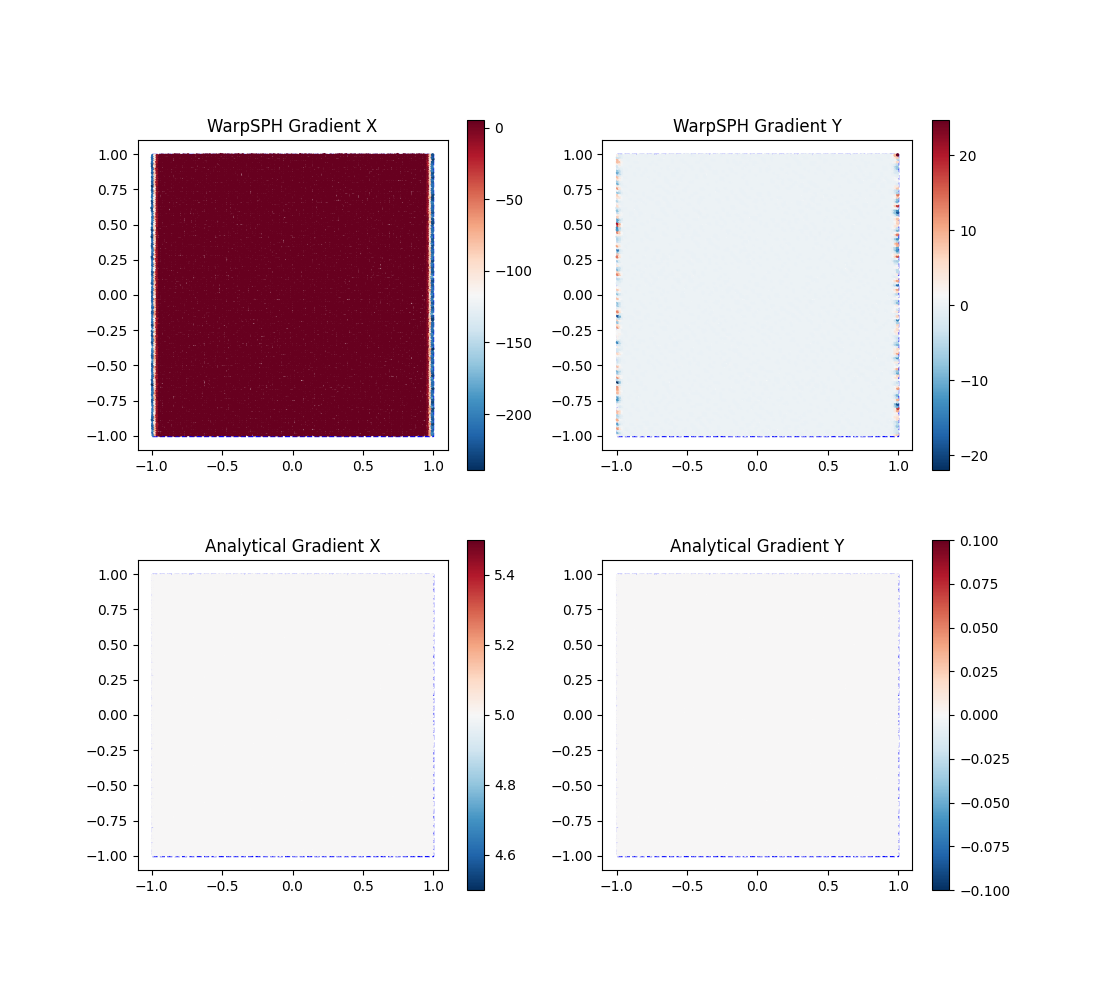

In [4]:
f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)
f_grad_y = torch.zeros_like(f_linear)

linear_gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)

print("Linear Gradient (WarpSPH): ", linear_gradient_warp)

mean_error_x = torch.mean(torch.abs(linear_gradient_warp[:,0] - f_grad_x))
mean_error_y = torch.mean(torch.abs(linear_gradient_warp[:,1] - f_grad_y))

print("Mean Absolute Error in X Gradient: ", mean_error_x.item())
print("Mean Absolute Error in Y Gradient: ", mean_error_y.item())

fig, axis = plt.subplots(2,2, figsize = (11,10), squeeze=False)
plotToAxis(fig, axis[0,0], particleState, linear_gradient_warp[:,0], "WarpSPH Gradient X", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[0,1], particleState, linear_gradient_warp[:,1], "WarpSPH Gradient Y", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,0], particleState, f_grad_x, "Analytical Gradient X", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,1], particleState, f_grad_y, "Analytical Gradient Y", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize);

In [5]:
f = torch.randn(numParticles, device=device, dtype=torch.float32)

f_smoothed = f.clone()

for _ in range(4):
    f_smoothed = warpOperation(
        queryParticles = particleState,
        queryValues = f_smoothed,
        operationProperties = OperationProperties(
            kernel = kernel,
            supportMode = supportMode,
            operation = WarpOperation.Interpolate,
        ),
        adjacency = adjacency,
        domain = domain,
    )

gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_smoothed,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)

gradient_warpNoAdjacency = warpOperation(
    queryParticles = particleState,
    queryValues = f_smoothed,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = None,
    domain = domain,
)


if not warpOnly:
    gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_smoothed,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        gradientMode=GradientMode.Difference,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
    )



Module sphWarpCore.operations.wp_interpolate c4dbeae load on device 'cuda:0' took 7.26 ms  (cached)
Module sphWarpCore.operations_grid.wp_gradient_grid 004f1d8 load on device 'cuda:0' took 7.10 ms  (cached)


In [6]:
gradient_warp - gradient_warpNoAdjacency

tensor([[ 2.3842e-07,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00],
        [ 0.0000e+00, -4.7684e-07],
        ...,
        [-2.3842e-07, -2.3842e-07],
        [ 0.0000e+00, -2.3842e-07],
        [-1.1921e-07, -1.1921e-07]], device='cuda:0')

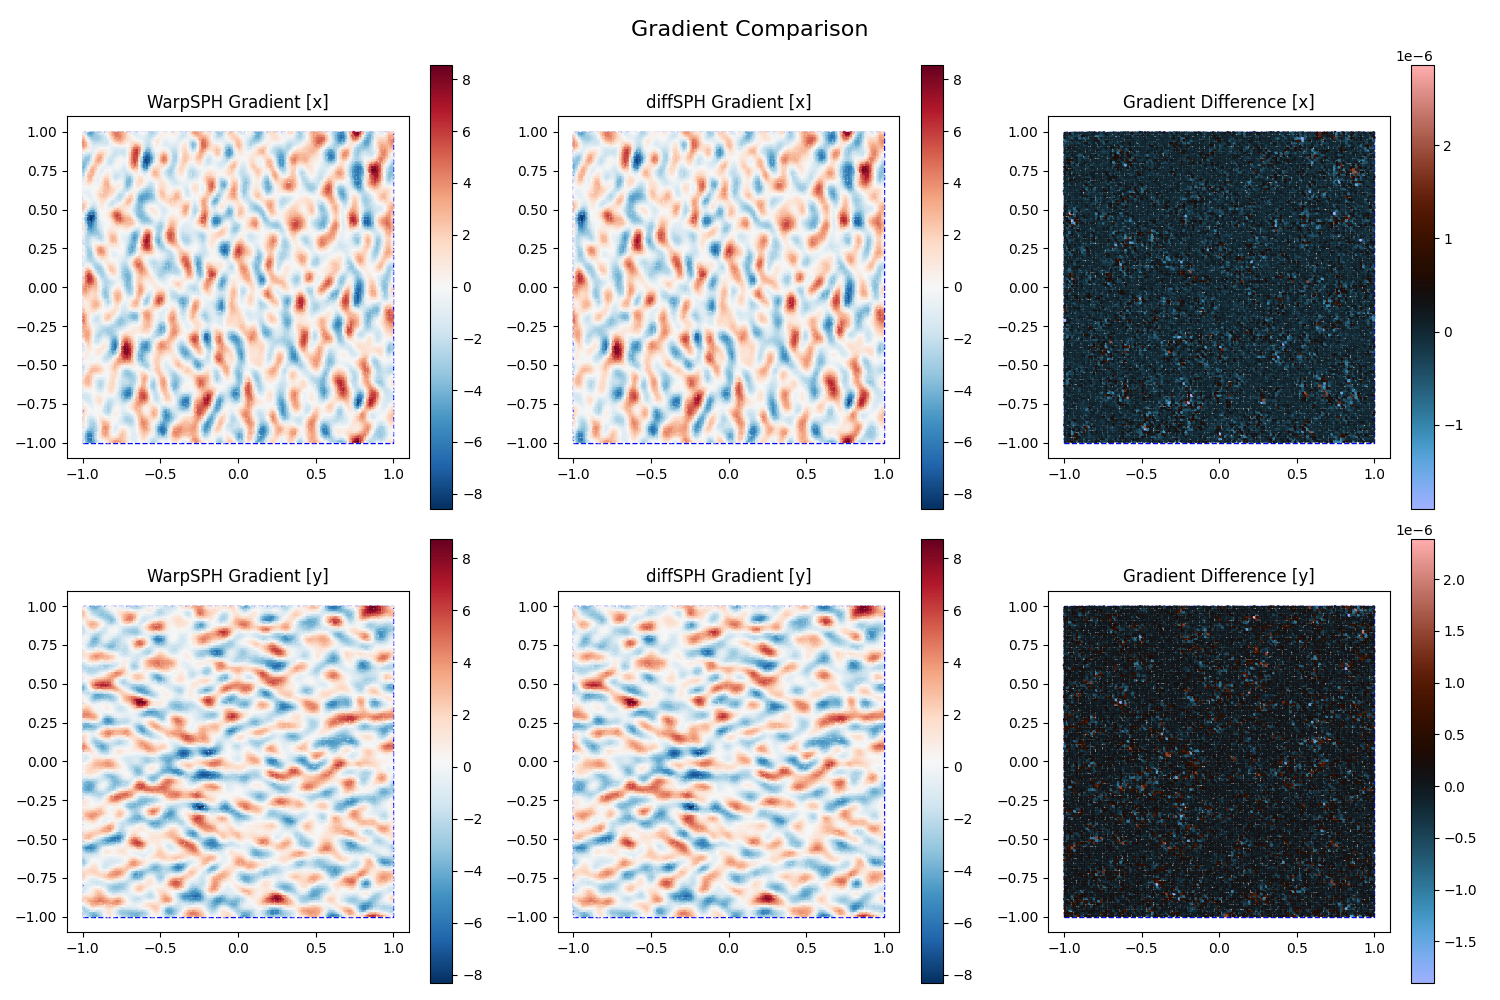

In [7]:
fig, axis = plt.subplots(2,3 if not warpOnly else 1, figsize = (15 if not warpOnly else 11,10), squeeze=False)
markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128


plotToAxis(fig, axis[0,0], particleState, gradient_warp[:,0], "WarpSPH Gradient [x]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,0], particleState, gradient_warp[:,1], "WarpSPH Gradient [y]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

if not warpOnly:
    plotToAxis(fig, axis[0,1], particleState, gradient_diffSPH[:,0], "diffSPH Gradient [x]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
    plotToAxis(fig, axis[1,1], particleState, gradient_diffSPH[:,1], "diffSPH Gradient [y]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

    diff_x = gradient_warp[:,0] - gradient_diffSPH[:,0]
    diff_y = gradient_warp[:,1] - gradient_diffSPH[:,1]

    plotToAxis(fig, axis[0,2], particleState, diff_x, "Gradient Difference [x]", 'berlin', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
    plotToAxis(fig, axis[1,2], particleState, diff_y, "Gradient Difference [y]", 'berlin', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

fig.suptitle("Gradient Comparison" if not warpOnly else "WarpSPH Gradient", fontsize = 16)
fig.tight_layout()


In [8]:
from diffSPH.modules.CRKSPH import computeCRKVolume, computeGeometricMoments, computeCRKTerms, computeCRKDensity, computeVelocityTensor, computeCRKdvdt, computeCRKdudt
from diffSPH.enums import SupportScheme as DiffSPHSupportScheme, KernelType as DiffSPHKernelType, KernelCorrectionScheme

f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)
f_grad_y = torch.zeros_like(f_linear)


In [9]:
gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain
)

gradient_warp_crk = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = crkState,
    queryVolumes = apparentVolume,
)


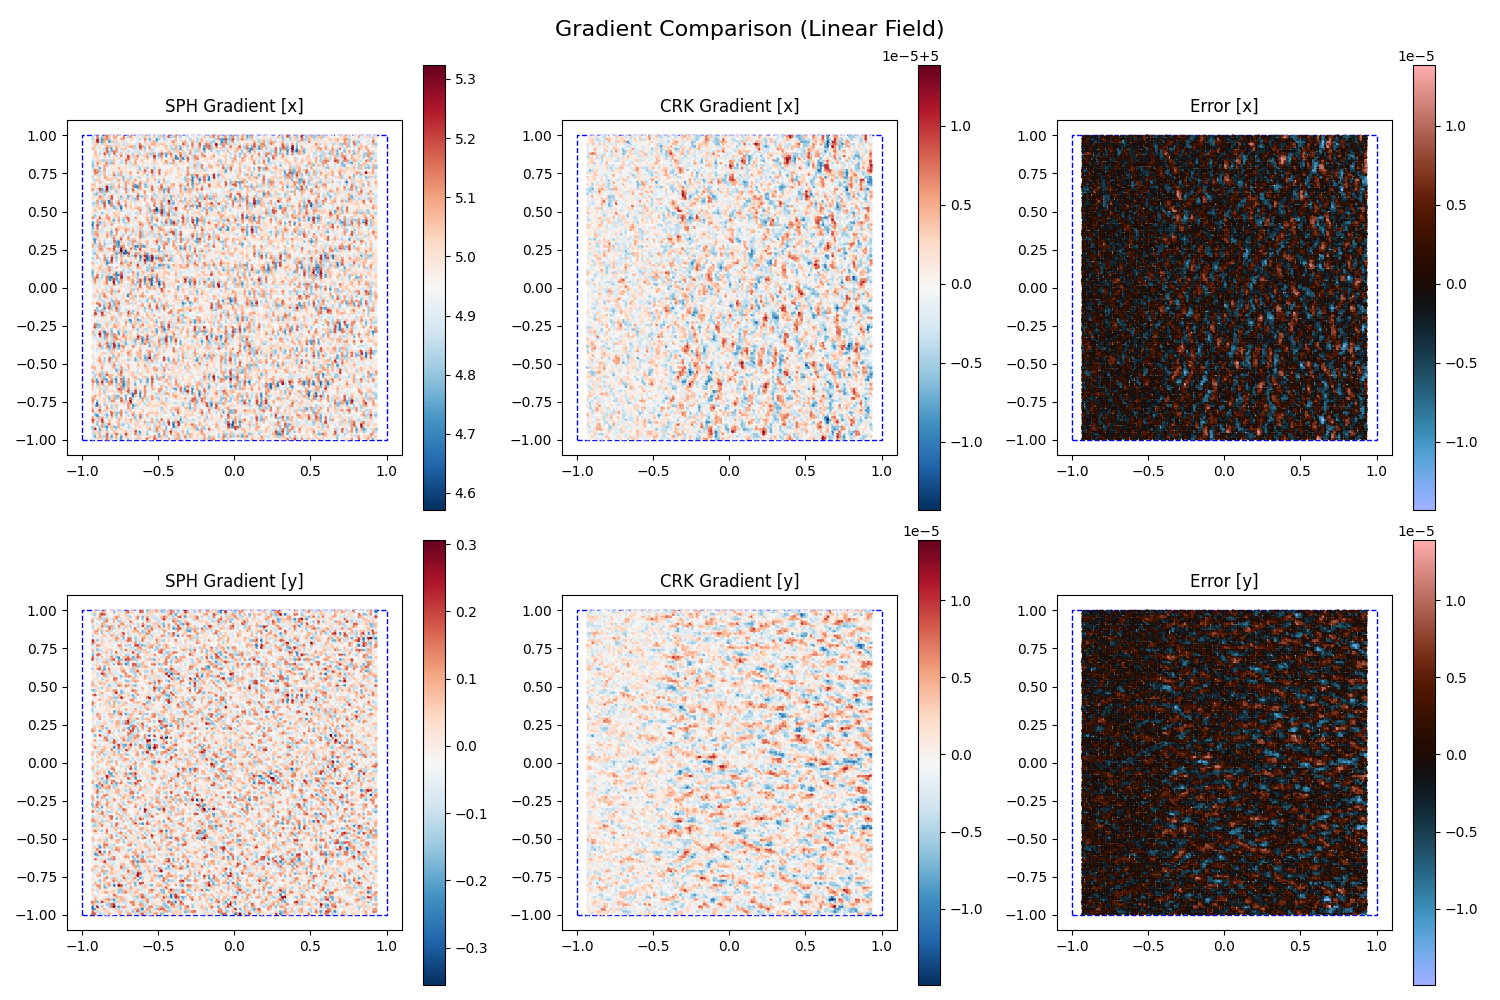

In [10]:
fig, axis = plt.subplots(2, 3, figsize = (15, 10 if not warpOnly else 10), squeeze=False)
mask = torch.logical_and(particleState.positions[:,0] > -1 + dx * 4, particleState.positions[:,0] < 1 - dx * 4)

plotToAxis(fig, axis[0,0], particleState, linear_gradient_warp[:,0], "SPH Gradient [x]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,0], particleState, linear_gradient_warp[:,1], "SPH Gradient [y]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

plotToAxis(fig, axis[0,1], particleState, gradient_warp_crk[:,0], "CRK Gradient [x]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,1], particleState, gradient_warp_crk[:,1], "CRK Gradient [y]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

err_x = gradient_warp_crk[:,0] - f_grad_x
err_y = gradient_warp_crk[:,1] - f_grad_y

plotToAxis(fig, axis[0,2], particleState, err_x, "Error [x]", 'berlin', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,2], particleState, err_y, "Error [y]", 'berlin', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

fig.suptitle("Gradient Comparison (Linear Field)", fontsize = 16)
fig.tight_layout()

In [11]:
f_interp_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = crkState,
    queryVolumes = apparentVolume,
)

f_interp_warp_noCRK = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = None,
    queryVolumes = None,
)

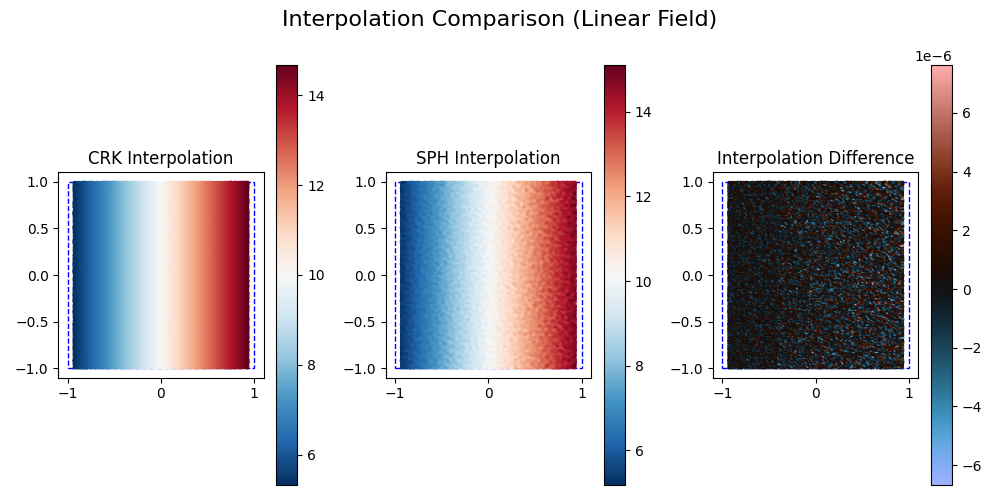

In [12]:
fig, axis = plt.subplots(1, 3, figsize = (10,5), squeeze=False)
mask = torch.logical_and(particleState.positions[:,0] > -1 + dx * 4, particleState.positions[:,0] < 1 - dx * 4)
plotToAxis(fig, axis[0,0], particleState, f_interp_warp, "CRK Interpolation", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[0,1], particleState, f_interp_warp_noCRK, "SPH Interpolation", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[0,2], particleState, f_interp_warp - f_linear, "Interpolation Difference", 'berlin', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
fig.suptitle("Interpolation Comparison (Linear Field)", fontsize = 16)
fig.tight_layout()

In [13]:
device = torch.device('cpu')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
targetNumNeighbors = 8
nx = 128
dim = 1
numParticles = nx**dim

warpOnly = False
periodic = True

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128
dx = 2.0 / nx

particleState, domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly)


Module sphWarpCore.operations.wp_density 667d662 load on device 'cuda:0' took 13.19 ms  (cached)


In [14]:
# particleState.supports = particleState.supports + torch.sin(particleState.positions[:,0] * np.pi) * 0.2 * particleState.supports

particleState.supports = particleState.supports + torch.randn_like(particleState.supports) * 0.25 * particleState.supports

adjacency, adjacency_warp_gpu, adjacency_warp_cpu = timeFunction(radiusSearchCompactHashMap,
        particleState, domain, 
        mode = SupportScheme.SuperSymmetric,
        hashMapLengthMode = HashMapLengthMode.Fixed, fixedHashMapLength = 4096
    )

apparentVolume, crkDensity, crkState = computeCRKFactors(particleState, domain, kernel, adjacency = adjacency)

Module sphWarpCore.crk.crk_volume 6c698fa load on device 'cuda:0' took 7.54 ms  (cached)
Module sphWarpCore.crk.crk_moments 6527f63 load on device 'cuda:0' took 9.78 ms  (cached)
Module sphWarpCore.crk.crk_density c09b0f7 load on device 'cuda:0' took 6.56 ms  (cached)


In [15]:
f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)


In [ ]:
f_interp_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = SupportScheme.Scatter,
        operation = WarpOperation.Interpolate,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = crkState,
    queryVolumes = apparentVolume,
)

f_interp_warp_noCRK = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = None,
    queryVolumes = None,
)

gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain
)

gradient_warp_crk = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = SupportScheme.Scatter,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = crkState,
    queryVolumes = apparentVolume,
)


Text(0.5, 1.0, 'Gradient Error')

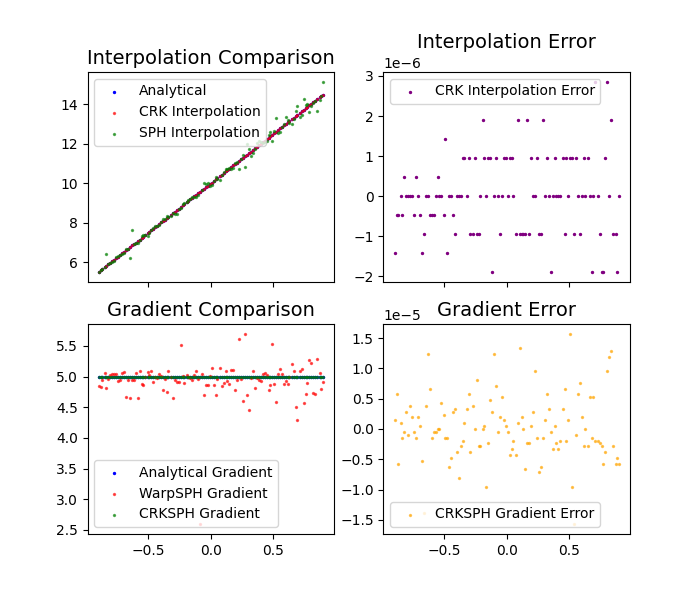

In [22]:
fig, axis = plt.subplots(2, 2, figsize = (7,6), squeeze=False, sharex=True)
mask = torch.logical_and(particleState.positions[:,0] > -1 + dx * 6, particleState.positions[:,0] < 1 - dx * 6)
axis[0,0].scatter(particleState.positions[mask,0].cpu(), f_linear[mask].cpu(), s=markerSize, c='blue', label='Analytical')
axis[0,0].scatter(particleState.positions[mask,0].cpu(), f_interp_warp[mask].cpu(), s=markerSize, c='red', label='CRK Interpolation', alpha=0.6)
axis[0,0].scatter(particleState.positions[mask,0].cpu(), f_interp_warp_noCRK[mask].cpu(), s=markerSize, c='green', label='SPH Interpolation', alpha=0.6)
axis[0,0].legend()
axis[0,0].set_title("Interpolation Comparison", fontsize=14)

axis[1,0].scatter(particleState.positions[mask,0].cpu(), f_grad_x[mask].cpu(), s=markerSize, c='blue', label='Analytical Gradient')
axis[1,0].scatter(particleState.positions[mask,0].cpu(), gradient_warp[mask,0].cpu(), s=markerSize, c='red', label='WarpSPH Gradient', alpha=0.6)
axis[1,0].scatter(particleState.positions[mask,0].cpu(), gradient_warp_crk[mask,0].cpu(), s=markerSize, c='green', label='CRKSPH Gradient', alpha=0.6)
axis[1,0].legend()
axis[1,0].set_title("Gradient Comparison", fontsize=14)

axis[0,1].scatter(particleState.positions[mask,0].cpu(), (f_interp_warp - f_linear)[mask].cpu(), s=markerSize, c='purple', label='CRK Interpolation Error')
# axis[0,1].scatter(particleState.positions[mask,0].cpu(), (f_interp_warp_noCRK - f_linear)[mask].cpu(), s=markerSize, c='orange', label='SPH Interpolation Error', alpha=0.6)
axis[0,1].legend()
axis[0,1].set_title("Interpolation Error", fontsize=14)

# axis[1,1].scatter(particleState.positions[mask,0].cpu(), (gradient_warp[:,0] - f_grad_x)[mask].cpu(), s=markerSize, c='purple', label='WarpSPH Gradient Error')
axis[1,1].scatter(particleState.positions[mask,0].cpu(), (gradient_warp_crk[:,0] - f_grad_x)[mask].cpu(), s=markerSize, c='orange', label='CRKSPH Gradient Error', alpha=0.6)
axis[1,1].legend()
axis[1,1].set_title("Gradient Error", fontsize=14)